In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Add src folder to path
sys.path.append(os.path.abspath("../src"))

In [2]:
from config.base_config import BaseConfig
from environment.financial_env import FinancialEnv
from agents.rl.train_ppo import train_ppo
from training.evaluate import evaluate

In [3]:
!python ../src/preprocessing/market_data.py

Processed data already exists


In [4]:
!python ../src/preprocessing/user_profiles.py

User profiles already exists


In [5]:
market_df = pd.read_csv("../data/processed/market_data.csv")
user_df = pd.read_csv("../data/processed/user_profiles.csv")

print(market_df.shape, user_df.shape)

(229, 7) (20000, 9)


In [6]:
market_df.head()

,Date,equity_return,debt_return,cash_return,volatility,drawdown,market_indicator
0,2007-01-01,0.0293,0.0441,0.0025,0.061391,0.000000,2
1,2007-02-01,-0.0826,0.0074,0.0025,0.065611,-0.082641,1
2,2007-03-01,0.0204,0.0182,0.0025,0.064439,-0.063965,2
3,2007-04-01,0.0697,0.0180,0.0025,0.061713,0.000000,2
4,2007-05-01,0.0509,-0.0048,0.0025,0.060363,0.000000,2


In [7]:
market_df.describe()

,equity_return,debt_return,cash_return,volatility,drawdown,market_indicator
count,229.000000,229.000000,229.0000,229.000000,229.000000,229.000000
mean,0.009891,0.000198,0.0025,0.056319,-0.080346,1.314410
std,0.059106,0.029689,0.0000,0.023002,0.108954,0.692575
min,-0.264100,-0.170600,0.0025,0.030889,-0.551184,0.000000
25%,-0.020700,-0.014500,0.0025,0.039207,-0.108584,1.000000
50%,0.009300,-0.000500,0.0025,0.044687,-0.042151,1.000000
75%,0.042300,0.014200,0.0025,0.070572,0.000000,2.000000
max,0.280700,0.120400,0.0025,0.121332,0.000000,2.000000


In [8]:
def plot_market_distributions(df):
    cols = df.columns.drop("Date")

    n_cols = 3
    n_rows = (len(cols) + 2) // 3

    plt.figure(figsize=(15, 4 * n_rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=50)
        plt.title(f"{col} Distribution")

    plt.tight_layout()
    plt.show()

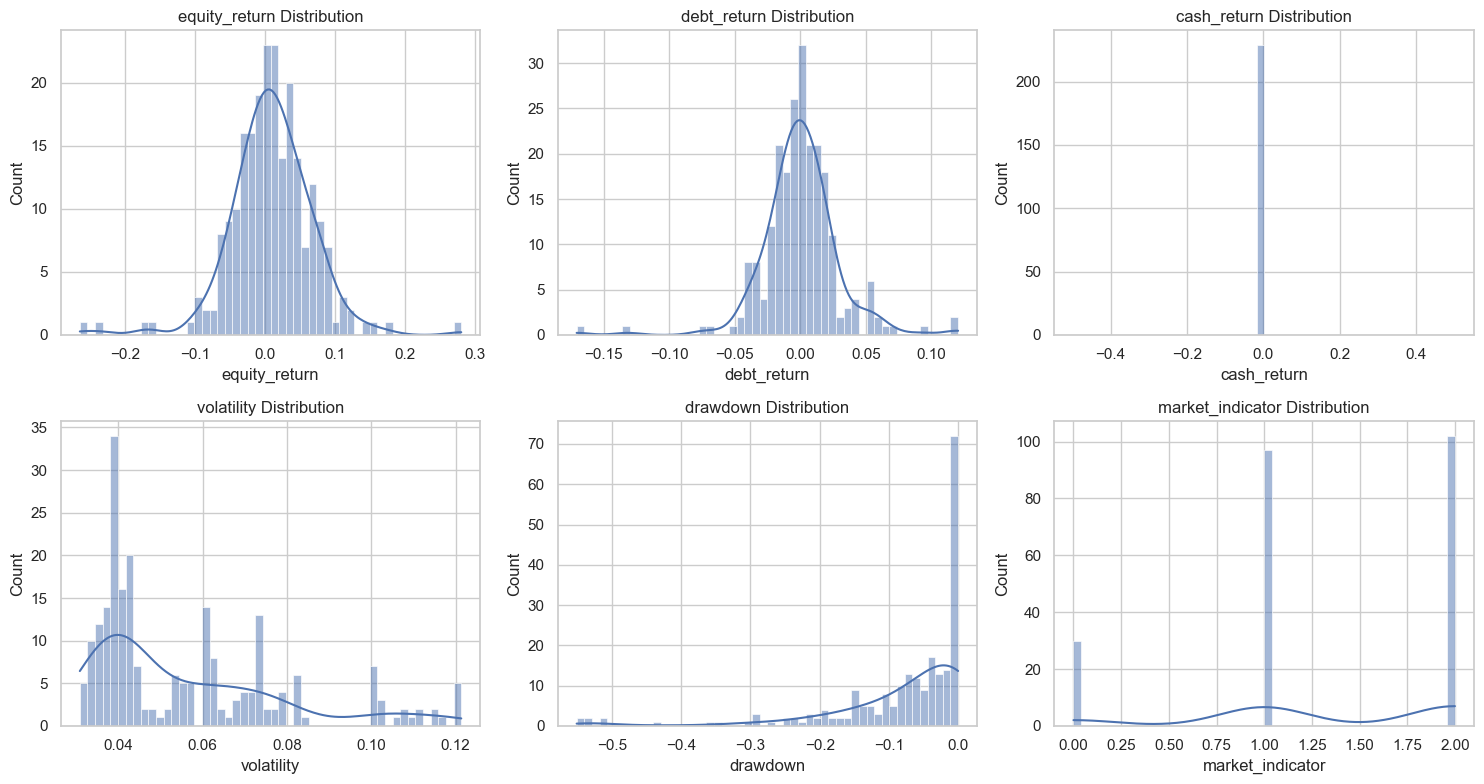

In [9]:
plot_market_distributions(market_df)

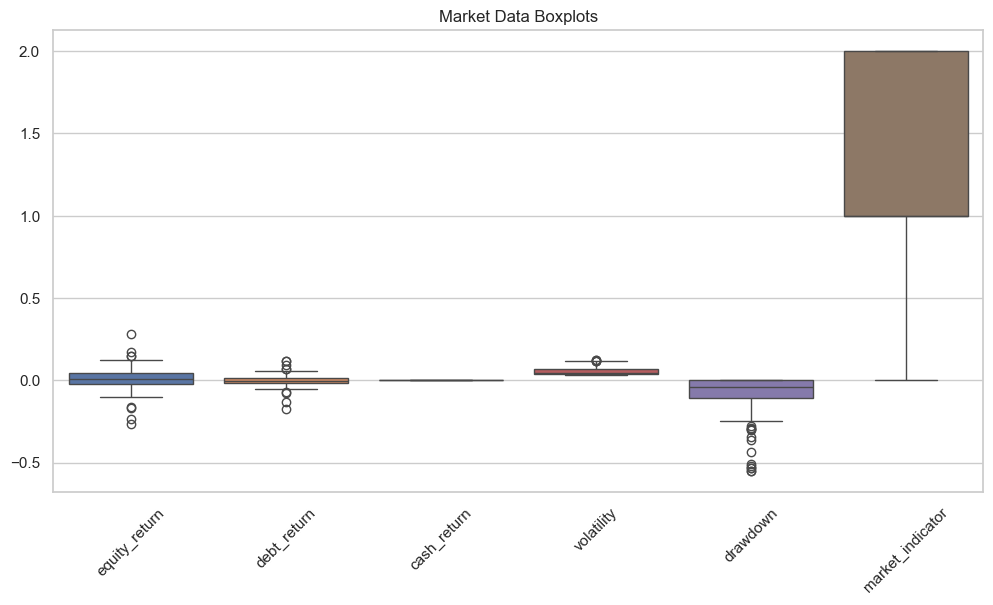

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=market_df.drop(columns=["Date"]))
plt.title("Market Data Boxplots")
plt.xticks(rotation=45)
plt.show()

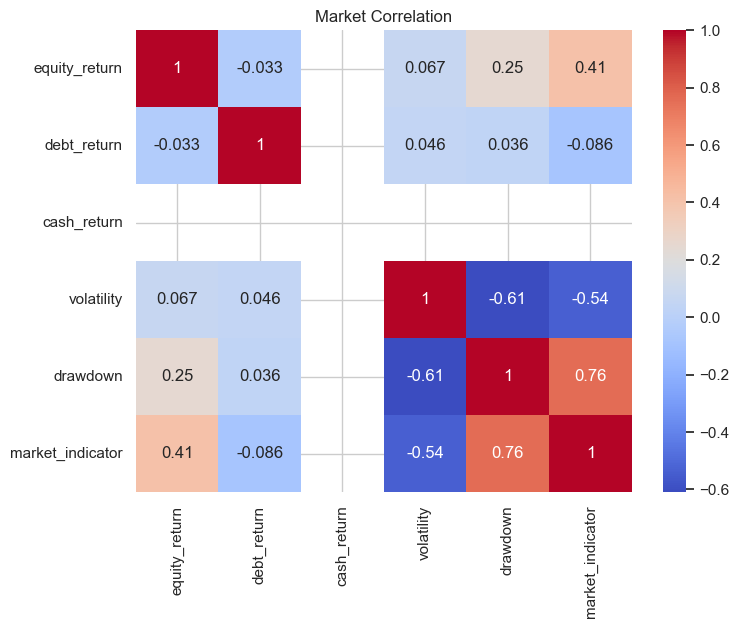

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(market_df.drop(columns=["Date"]).corr(), annot=True, cmap="coolwarm")
plt.title("Market Correlation")
plt.show()

In [12]:
user_df.head()

,wealth,age,goal,income,income_var,job_loss_prob,expense,emergency_buffer_months,risk_appetite
0,1670689,52,168,35765,0.30,0.008,32138,22,0.3
1,11456686,47,228,96369,0.15,0.004,55982,9,0.5
2,18344126,44,264,240095,0.05,0.001,126106,4,0.3
3,1469946,41,300,59394,0.05,0.001,46084,4,0.7
4,7573057,34,384,161107,0.05,0.001,76412,5,0.7


In [13]:
user_df.describe()

,wealth,age,goal,income,income_var,job_loss_prob,expense,emergency_buffer_months,risk_appetite
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1.528445e+07,40.476500,306.282000,99806.652200,0.135997,0.002629,60653.837800,8.035150,0.476420
std,3.038904e+07,11.008711,132.104526,73602.249429,0.084846,0.002112,37145.276425,4.013181,0.151067
min,0.000000e+00,22.000000,84.000000,20000.000000,0.050000,0.001000,11870.000000,4.000000,0.300000
25%,6.877405e+05,31.000000,192.000000,49040.500000,0.050000,0.001000,36018.000000,6.000000,0.300000
50%,3.744092e+06,40.000000,312.000000,75238.000000,0.150000,0.001000,48937.500000,7.000000,0.500000
75%,1.394271e+07,50.000000,420.000000,122527.250000,0.150000,0.004000,72416.250000,9.000000,0.500000
max,3.056249e+08,59.000000,528.000000,488849.000000,0.300000,0.008000,286121.000000,23.000000,0.700000


In [14]:
def plot_user_distributions(df):
    cols = df.columns

    n_cols = 3
    n_rows = (len(cols) + 2) // 3

    plt.figure(figsize=(15, 4 * n_rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=50)
        plt.title(f"{col} Distribution")

    plt.tight_layout()
    plt.show()

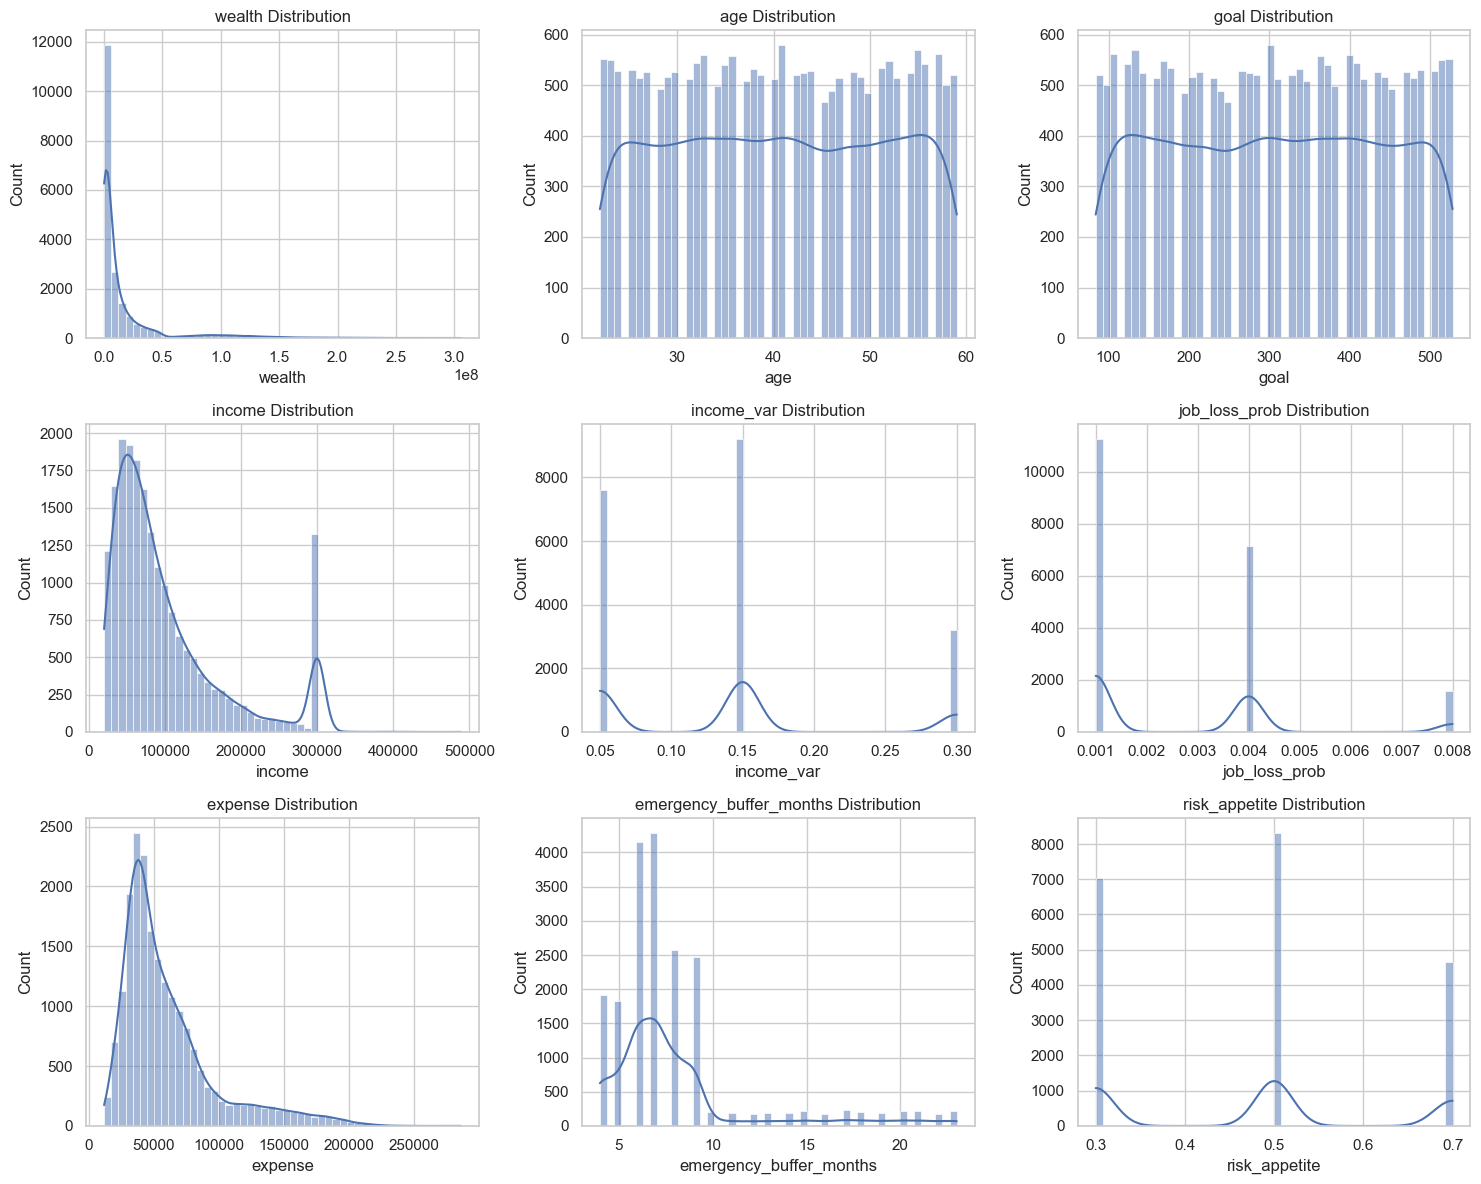

In [15]:
plot_user_distributions(user_df)

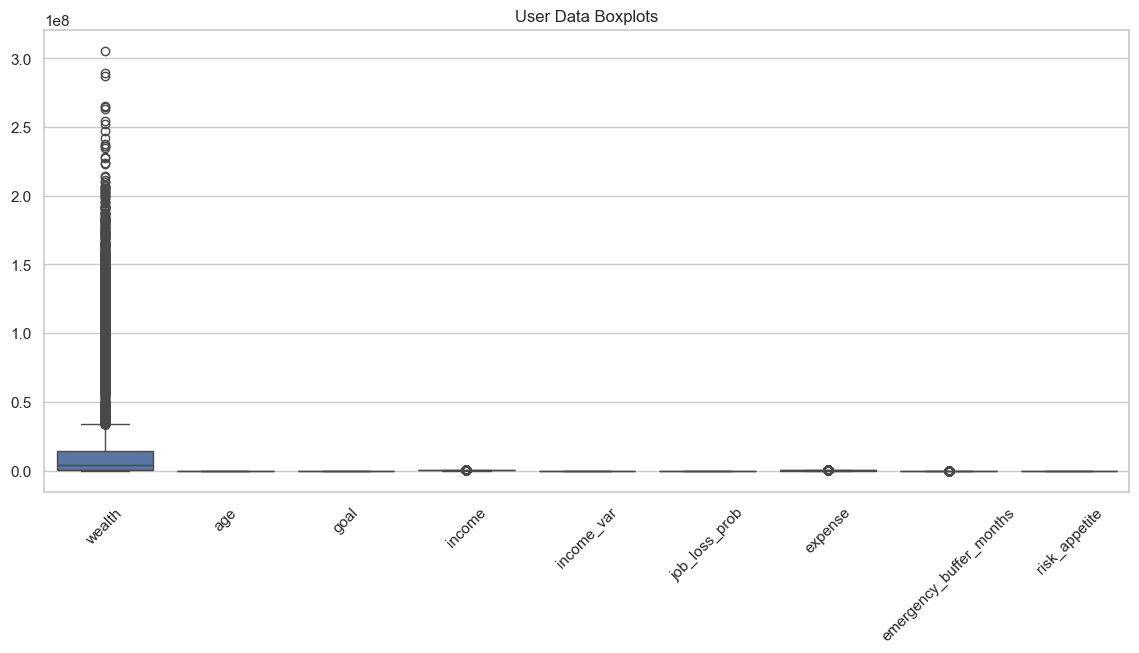

In [16]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=user_df)
plt.title("User Data Boxplots")
plt.xticks(rotation=45)
plt.show()

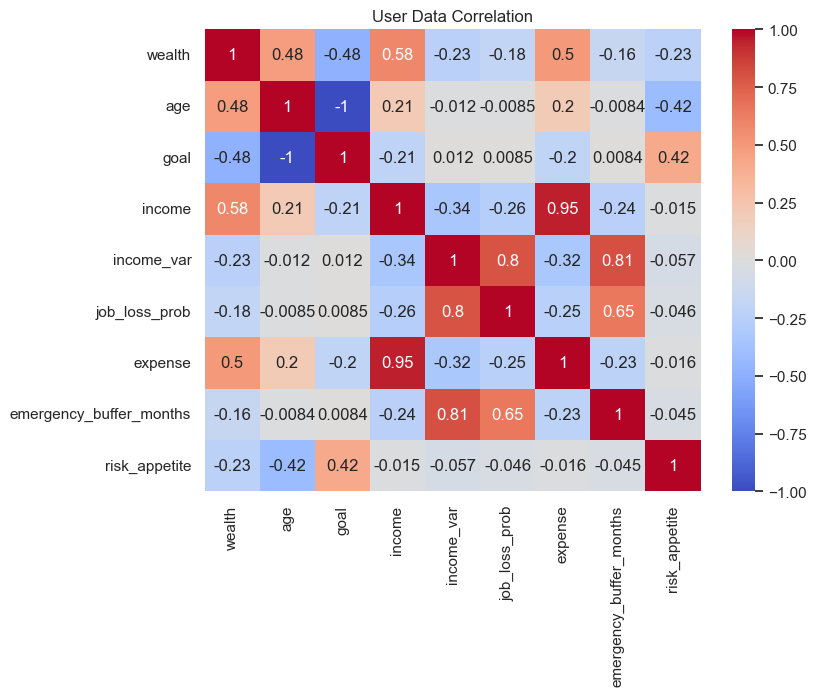

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(user_df.corr(), annot=True, cmap="coolwarm")
plt.title("User Data Correlation")
plt.show()

In [18]:
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

config = BaseConfig()

env = DummyVecEnv([lambda: FinancialEnv(market_df, user_df, config)])
env = VecNormalize(env, norm_obs=True, norm_reward=True)

obs = env.reset()
print(obs.shape)

(1, 17)


In [19]:
for _ in range(5):
    action = np.array([[0.3, 0.3, 0.4]])   # batch of 1

    obs, rewards, dones, infos = env.step(action)

    print("Reward:", rewards)

Reward: [10.]
Reward: [2.0856936]
Reward: [0.4338376]
Reward: [0.6599446]
Reward: [0.720334]


In [20]:
model = train_ppo(
    market_df=market_df,
    user_df=user_df,
    config=config,
    total_timesteps=100_000
)

Using cpu device
Training PPO...
Logging to ./outputs/tensorboard/ppo/PPO_34
-----------------------------
| time/              |      |
|    fps             | 728  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 380         |
|    iterations           | 2           |
|    time_elapsed         | 10          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.007168776 |
|    clip_fraction        | 0.0858      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.26       |
|    explained_variance   | -0.0342     |
|    learning_rate        | 0.0003      |
|    loss                 | 14.4        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00787    |
|    std                  | 1           |

In [21]:
results = evaluate(
    model=model,
    market_df=market_df,
    user_df=user_df,
    config=config,
    algo_name="ppo_test",
    num_episodes=5
)

print(results)

c:\Users\shrey\Downloads\Dynamic-Personal-Finance-Planner\src\training\evaluate.py:189: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(file_path)


Saved plot for user 11147
Saved plot for user 5796
Saved plot for user 9439
Saved plot for user 7570
Saved plot for user 9577
{'avg_final_wealth': 2644661533.7262573, 'median_final_wealth': 349571494.9431914, 'wealth_std': 3791792382.208907, 'avg_sharpe': 0.16901567215659202, 'avg_max_drawdown': -0.6866192850858902, 'ruin_probability': 0.0, 'avg_reward': 74.45420786291497}
